In [37]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 2 #random number (usually around 50?)

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    shuffle = True, #shuffle as False is bad for training, because the model sees only one class at a time.
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset) #batches of 32 each

68

In [6]:
68*32

2176

In [7]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())#convert tensor to numpy
    print(image_batch[0].numpy())
    print(image_batch[0].shape)


(32, 256, 256, 3)
[2 2 0 0 0 1 1 1 2 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 2 1 1]
[[[198. 185. 194.]
  [176. 163. 172.]
  [157. 144. 153.]
  ...
  [169. 149. 158.]
  [160. 140. 149.]
  [153. 133. 142.]]

 [[152. 139. 148.]
  [178. 165. 174.]
  [171. 158. 167.]
  ...
  [154. 134. 143.]
  [148. 128. 137.]
  [129. 109. 118.]]

 [[182. 169. 178.]
  [167. 154. 163.]
  [178. 165. 174.]
  ...
  [123. 103. 112.]
  [192. 172. 181.]
  [155. 135. 144.]]

 ...

 [[139. 119. 128.]
  [144. 124. 133.]
  [151. 131. 140.]
  ...
  [121. 102. 108.]
  [141. 122. 128.]
  [206. 187. 193.]]

 [[145. 125. 134.]
  [148. 128. 137.]
  [153. 133. 142.]
  ...
  [183. 164. 170.]
  [121. 102. 108.]
  [162. 143. 149.]]

 [[147. 127. 136.]
  [148. 128. 137.]
  [148. 128. 137.]
  ...
  [140. 121. 127.]
  [134. 115. 121.]
  [182. 163. 169.]]]
(256, 256, 3)


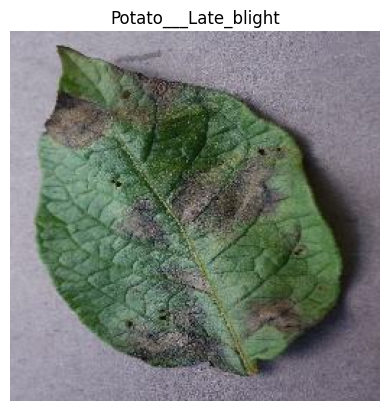

In [8]:
for image_batch, label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]])
    plt.axis("off")

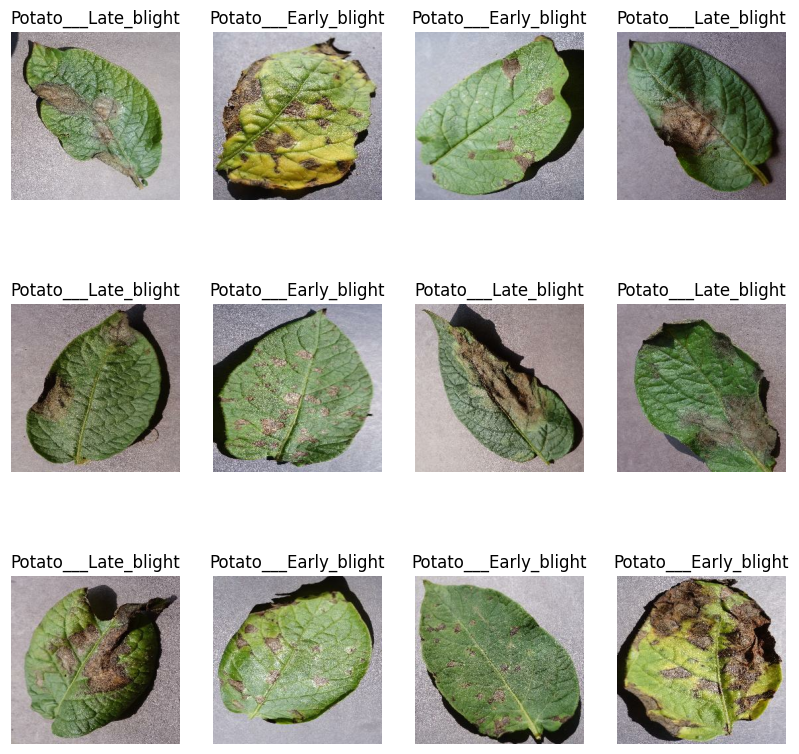

In [9]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

###Train-Test split

80% -> training
20% -> 10% validation, 10% test

In [10]:
train_size = 0.8
len(dataset) * train_size

54.400000000000006

In [11]:
train_ds = dataset.take(54) #first 54
len(train_ds)

54

In [12]:
remain_ds = dataset.skip(54)
len(remain_ds)

14

In [13]:
val_size = 0.1
len(dataset) * val_size

6.800000000000001

In [14]:
val_ds = remain_ds.take(6)
len(val_ds)

6

In [15]:
test_ds = remain_ds.skip(6)
len(test_ds)

8

In [16]:
def get_dataset_partitions(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 1000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed =12)#shuffle_size controls how many elements from the dataset TensorFlow will load into memory at once to perform the shuffle. It is the size of the shuffle buffer.

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


In [17]:
#train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

##Dataset Optimization for training performance

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

##Scaling dataset

In [19]:
#When the model starts predicting, any image that is not of 256*256 is supplied, this layer will transform it into relevant size
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255) #scale images by 255
])

#data augmentation

if the new data is rotated or of different contrast, such things are taken into consideration using data augmentation, and additional training image are generated out of already existing images, which horizontally or vertically flipped and of different contrast

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])#generate new samples

#CNN

In [21]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),#32 is the random number of filters
    layers.MaxPooling2D((2,2)),#preserving features and reducing the size of the image
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation="softmax") #softmax provide probability of classes
])

In [22]:
model.build(input_shape=input_shape)

In [23]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (32, 127, 127, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                 

#compile

In [24]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [25]:
history = model.fit(
    train_ds,
    epochs = 2,#50
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds
)

Epoch 1/2


54/54 [==============================] - 78s 1s/step - loss: 0.8518 - accuracy: 0.5145 - val_loss: 0.8932 - val_accuracy: 0.5417
Epoch 2/2
54/54 [==============================] - 70s 1s/step - loss: 0.6629 - accuracy: 0.6863 - val_loss: 0.5104 - val_accuracy: 0.7812


In [26]:
scores = model.evaluate(test_ds)

8/8 [==============================] - 3s 228ms/step - loss: 0.5205 - accuracy: 0.7759


In [27]:
scores #loss,accuracy

[0.5205079913139343, 0.7758620977401733]

In [28]:
history

In [29]:
history.params

{'verbose': 1, 'epochs': 2, 'steps': 54}

In [30]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [31]:
history.history['accuracy']

[0.5144675970077515, 0.6863425970077515]

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

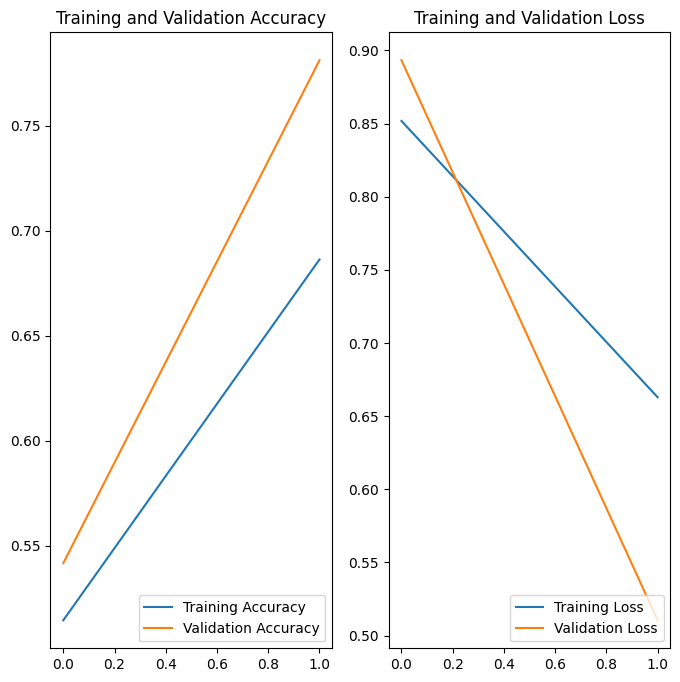

In [33]:
plt.figure(figsize = (8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label = "Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label = "Validation Accuracy")
plt.legend(loc = 'lower right')
plt.title("Training and Validation Accuracy")


plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label = "Training Loss")
plt.plot(range(EPOCHS), val_loss, label = "Validation Loss")
plt.legend(loc = 'lower right')
plt.title("Training and Validation Loss")
plt.show()


first image's actual label: Potato___healthy
1/1 [==============================] - 0s 306ms/step
first image's predicted label: Potato___Late_blight


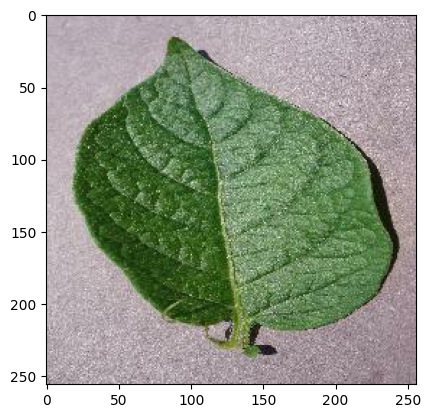

In [34]:
for image_batch, label_batch in test_ds.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()

    print("first image's actual label:", class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print("first image's predicted label:",class_names[np.argmax(batch_prediction[0])])

In [35]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) #create batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 45ms/step


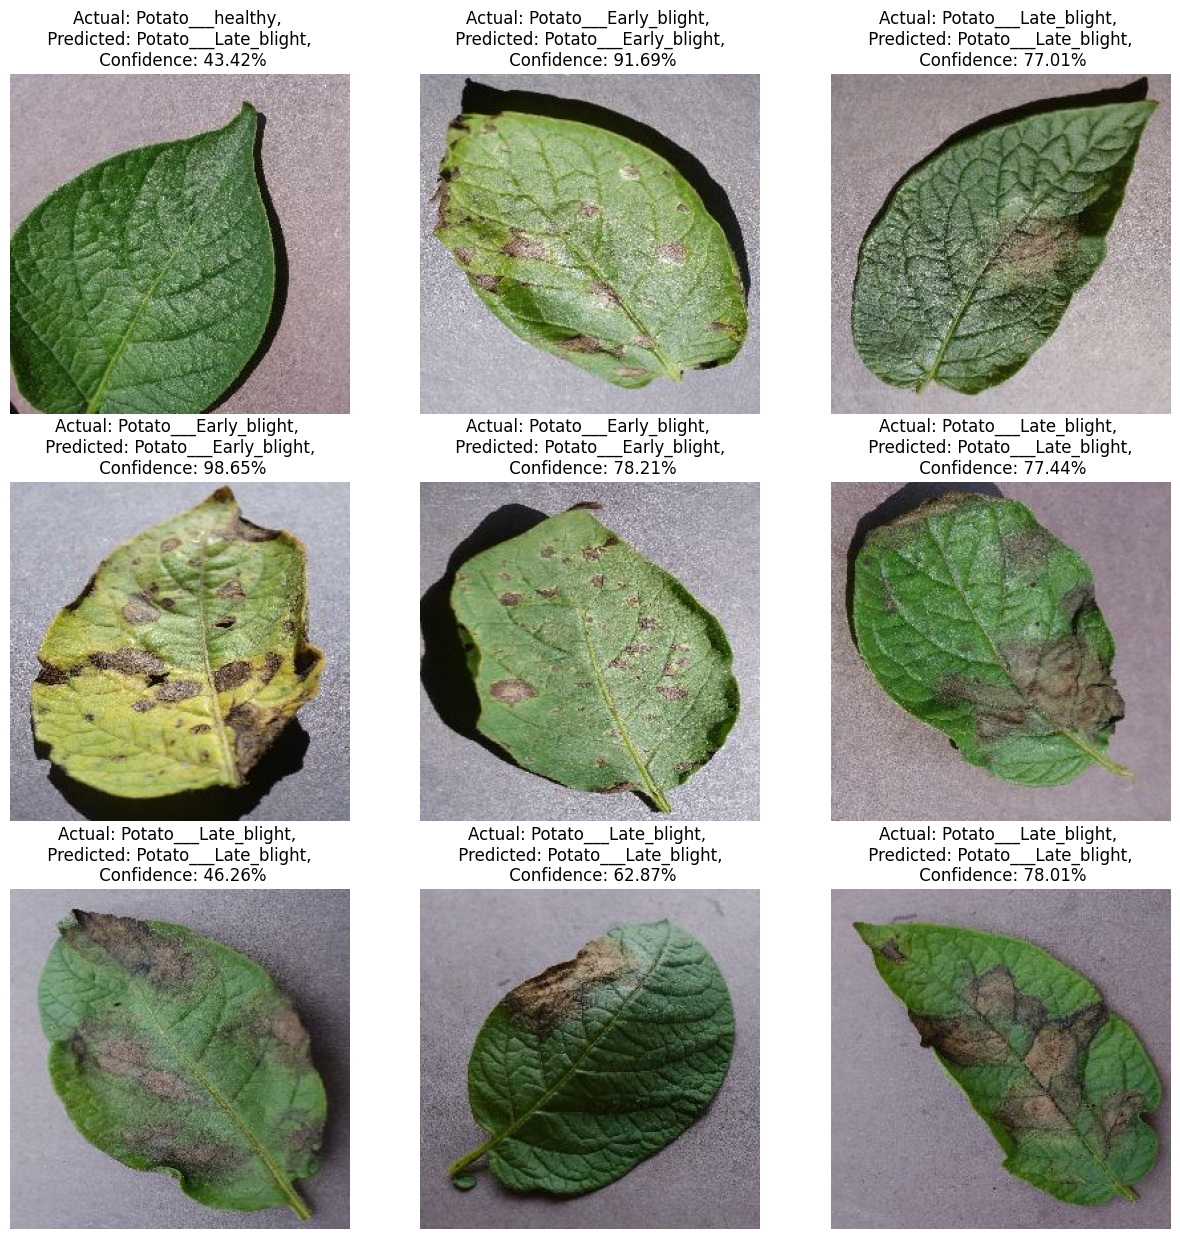

In [39]:
plt.figure(figsize = (15, 15)) #to resize images
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class,confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}, \n Confidence: {confidence}%")

        plt.axis("off")

In [ ]:
model_version = 1
#model.save(f"models/{model_version}")

INFO:tensorflow:Assets written to: models/1\assets


INFO:tensorflow:Assets written to: models/1\assets
